In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import locale
locale.setlocale( locale.LC_ALL, 'en_US.UTF-8' )

'en_US.UTF-8'

In [2]:
dataframe = pd.read_csv("/Users/raghav/Documents/Programs/python/ml/datasets/googl-income-stmt.csv")

In [3]:
dataframe.drop('ttm', axis = 1, inplace=True)
dataframe.info()
print(f'SHAPE : {dataframe.shape}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Breakdown   17 non-null     object
 1   12|30|2018  17 non-null     object
 2   12|30|2017  17 non-null     object
 3   12|30|2016  17 non-null     object
dtypes: object(4)
memory usage: 676.0+ bytes
SHAPE : (17, 4)


In [4]:
dataframe.head()

,Breakdown,12|30|2018,12|30|2017,12|30|2016
0,Total Revenue,"136,819,000","110,855,000","90,272,000"
1,Cost of Revenue,"59,549,000","45,583,000","35,138,000"
2,Gross Profit,"77,270,000","65,272,000","55,134,000"
3,Research Development,"21,419,000","16,625,000","13,948,000"
4,Selling General and Administrative,"24,459,000","19,765,000","17,470,000"


In [5]:
dataframe.isnull().sum()

Breakdown     0
12|30|2018    0
12|30|2017    0
12|30|2016    0
dtype: int64

In [6]:
dataframe.dropna(inplace=True)

In [7]:
dataframe.isnull().sum()

Breakdown     0
12|30|2018    0
12|30|2017    0
12|30|2016    0
dtype: int64

In [8]:
# csv number to int

new_ls_2016 = [locale.atoi(i) for i in dataframe['12|30|2016']]

new_ls_2017 = [locale.atoi(j) for j in dataframe['12|30|2017']]

new_ls_2018 = [locale.atoi(k) for k in dataframe['12|30|2018']]

#new_ttm = [locale.atoi(l) for l in dataframe['ttm']]

dataframe['12|30|2016'] = new_ls_2016
dataframe['12|30|2017'] = new_ls_2017
dataframe['12|30|2018'] = new_ls_2018
#dataframe['ttm'] = new_ttm

In [9]:
dataframe.head()

,Breakdown,12|30|2018,12|30|2017,12|30|2016
0,Total Revenue,136819000,110855000,90272000
1,Cost of Revenue,59549000,45583000,35138000
2,Gross Profit,77270000,65272000,55134000
3,Research Development,21419000,16625000,13948000
4,Selling General and Administrative,24459000,19765000,17470000


array([[<Axes: title={'center': '12|30|2018'}>,
        <Axes: title={'center': '12|30|2017'}>],
       [<Axes: title={'center': '12|30|2016'}>, <Axes: >]], dtype=object)

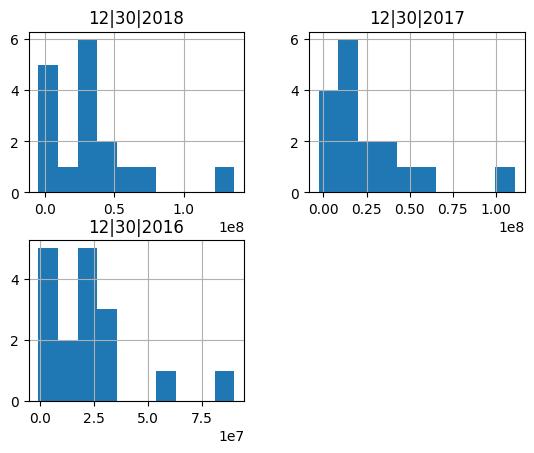

In [10]:
dataframe.hist()

In [11]:
dataframe.corr()

/var/folders/yn/b2s7jvrj5ll2svjntbmz70n40000gn/T/ipykernel_7644/4279439629.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataframe.corr()


,12|30|2018,12|30|2017,12|30|2016
12|30|2018,1.000000,0.977003,0.996312
12|30|2017,0.977003,1.000000,0.983813
12|30|2016,0.996312,0.983813,1.000000


In [12]:
dataframe.median()

/var/folders/yn/b2s7jvrj5ll2svjntbmz70n40000gn/T/ipykernel_7644/2007773594.py:1: FutureWarning: The default value of numeric_only in DataFrame.median is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataframe.median()


12|30|2018    30736000.0
12|30|2017    16625000.0
12|30|2016    19478000.0
dtype: float64

In [13]:
dataframe.describe()

,12|30|2018,12|30|2017,12|30|2016
count,1.700000e+01,1.700000e+01,1.700000e+01
mean,3.323249e+07,2.574403e+07,2.265066e+07
std,3.476724e+07,2.840244e+07,2.289532e+07
min,-5.071000e+06,-2.736000e+06,-6.620000e+05
25%,4.177000e+06,1.266200e+07,4.672000e+06
50%,3.073600e+07,1.662500e+07,1.947800e+07
75%,4.042700e+07,3.579700e+07,2.986000e+07
max,1.368190e+08,1.108550e+08,9.027200e+07


In [14]:
dataframe.skew()

/var/folders/yn/b2s7jvrj5ll2svjntbmz70n40000gn/T/ipykernel_7644/194550592.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataframe.skew()


12|30|2018    1.734761
12|30|2017    1.879306
12|30|2016    1.738169
dtype: float64

In [15]:
dataframe.kurt()

/var/folders/yn/b2s7jvrj5ll2svjntbmz70n40000gn/T/ipykernel_7644/4211245790.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  dataframe.kurt()


12|30|2018    4.180274
12|30|2017    4.331204
12|30|2016    4.026916
dtype: float64

In [16]:
q1 = np.percentile(dataframe['12|30|2018'],25)
q3 = np.percentile(dataframe['12|30|2018'],75)
q2 = q3 - q1

print(f'Q1 : {q1}')
print(f'Q2 : {q2}')
print(f'Q3 : {q3}')


Q1 : 4177000.0
Q2 : 36250000.0
Q3 : 40427000.0


<Axes: >

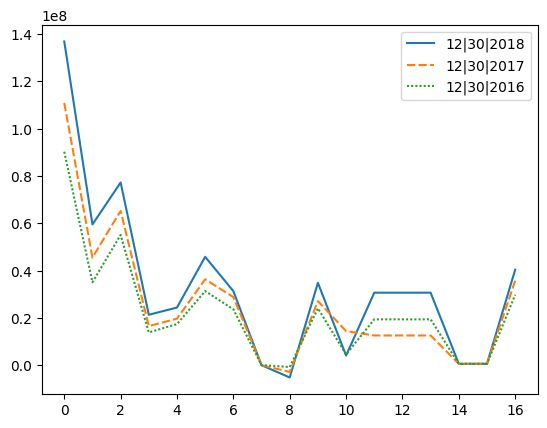

In [17]:
sns.lineplot(dataframe)

In [18]:
tbl = pd.pivot_table(dataframe, index ='12|30|2016', values ='12|30|2018',aggfunc = "sum")
tbl

,12|30|2018
12|30|2016,
-662000,-5071000
124000,114000
687782,695070
699390,703341
4672000,4177000
13948000,21419000
17470000,24459000
19478000,92208000
23716000,31392000


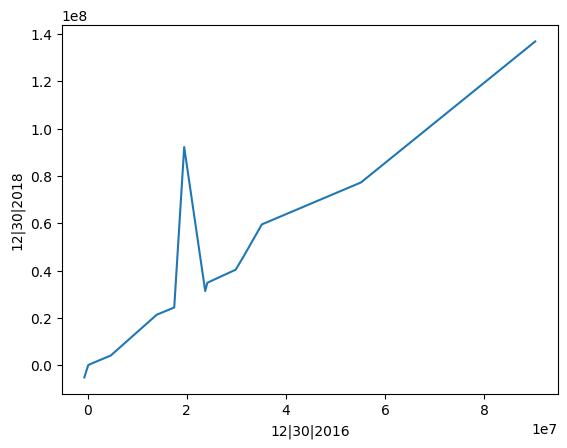

In [19]:
sns.lineplot(x = '12|30|2016', y = '12|30|2018',data = tbl)
plt.show()